# scDEF tutorial — two batches of PBMCs

Two batches of healthy PBMCs (donors `pbmc1` / `pbmc2`, one Drop-seq run each). They share the same cell types, so almost all between-batch variation is **technical**. This notebook shows scDEF's batch integration and the **standard batch-interpretation procedure**: fit a reference with `batch_key`, then `decompose_batch_effects` and inspect layer 0 to decide what is technical vs biological. The interferon notebook runs the *same* procedure and reaches the opposite conclusion.

> **Running this notebook.** Fitting is the slow step — run top-to-bottom once; the fitted model is saved at the end, so you can re-open it with `scd.scDEF.load(...)` instead of re-fitting. The steps follow the reference [analysis workflow](../repo/docs/workflow.md).

## Known markers (for signature validation)

In [1]:
markers = {
    'CD4+ T cell': ['CD3D', 'CD3E', 'CD3G', 'TRAC', 'CD4', 'TCF7', 'CD27', 'IL7R'],
    'Cytotoxic T cell': ['CD3D', 'CD3E', 'CD3G', 'TRAC', 'CD8A', 'CD8B', 'GZMK', 'CCL5', 'NKG7'],
    'CD14+ monocyte': ['VCAN', 'FCN1', 'S100A8', 'S100A9', 'CD14', 'ITGAL', 'ITGAM', 'CSF3R',
                       'CSF1R', 'CX3CR1', 'TYROBP', 'LYZ', 'S100A12'],
    'CD16+ monocyte': ['FCN1', 'FCGR3A', 'FCGR3B', 'ITGAL', 'ITGAM', 'CSF3R', 'CSF1R', 'CX3CR1',
                       'CDKN1C', 'MS4A7'],
    'Dendritic cell': ['HLA-DPB1', 'HLA-DPA1', 'HLA-DQA1', 'ITGAX', 'CD1C', 'FCER1A', 'CLEC10A',
                       'FCGR2B', 'MS4A1', 'CD79A', 'CD79B'],
    'Plasmacytoid dendritic cell': ['IL3RA', 'GZMB', 'JCHAIN', 'IRF7', 'TCF4', 'LILRA4', 'CLEC4C'],
    'B cell': ['CD19', 'MS4A1', 'CD79A', 'CD79B', 'MZB1', 'IGHD', 'IGHM'],
    'Natural killer cell': ['NCAM1', 'NKG7', 'KLRB1', 'KLRD1', 'KLRF1', 'KLRC1', 'KLRC2', 'KLRC3',
                            'KLRC4', 'FCGR3A', 'FCGR3B', 'ITGAL', 'ITGAM', 'FCER1G'],
    'Megakaryocyte': ['PF4', 'PPBP', 'ITGA2B', 'NRGN', 'TUBB1', 'SPARC', 'RGS18', 'GNG11'],
}

## Load packages and data

In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
import scdef as scd
import matplotlib.pyplot as plt

In [3]:
adata = sc.read_h5ad('../scdef_data/pbmcs_data/pbmcsca.h5ad')
# One technology (Drop-seq); the two donors pbmc1/pbmc2 are the two batches.
adata = adata[adata.obs['Method'] == 'Drop-seq'].copy()
adata.obs['Experiment'].value_counts()

Experiment
pbmc2    3362
pbmc1    3222
Name: count, dtype: int64

In [4]:
# QC + counts layer (following the paper preprocessing).
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=10)
adata.var['mt'] = adata.var_names.str.startswith('MT-')
adata.var['rb'] = adata.var_names.str.startswith('RPS') | adata.var_names.str.startswith('RPL')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt', 'rb'], percent_top=None, log1p=False, inplace=True)
adata = adata[adata.obs.n_genes_by_counts < 2000, :]
adata = adata[adata.obs.pct_counts_mt < 8, :]
adata.layers['counts'] = adata.X.toarray()

/tmp/ipykernel_430006/1256034521.py:9: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata.layers['counts'] = adata.X.toarray()


In [5]:
# HVG on the counts, per batch; keep marker genes; then a scanpy embedding for the colors.
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=4000, layer='counts',
                            batch_key='Experiment')
for g in {x for gs in markers.values() for x in gs}:
    if g in adata.var_names:
        adata.var.loc[g, 'highly_variable'] = True
adata = adata[:, adata.var.highly_variable].copy()
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)

/tmp/ipykernel_430006/488915410.py:5: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs['CellType'] = adata.obs['CellType'].replace(stypes)


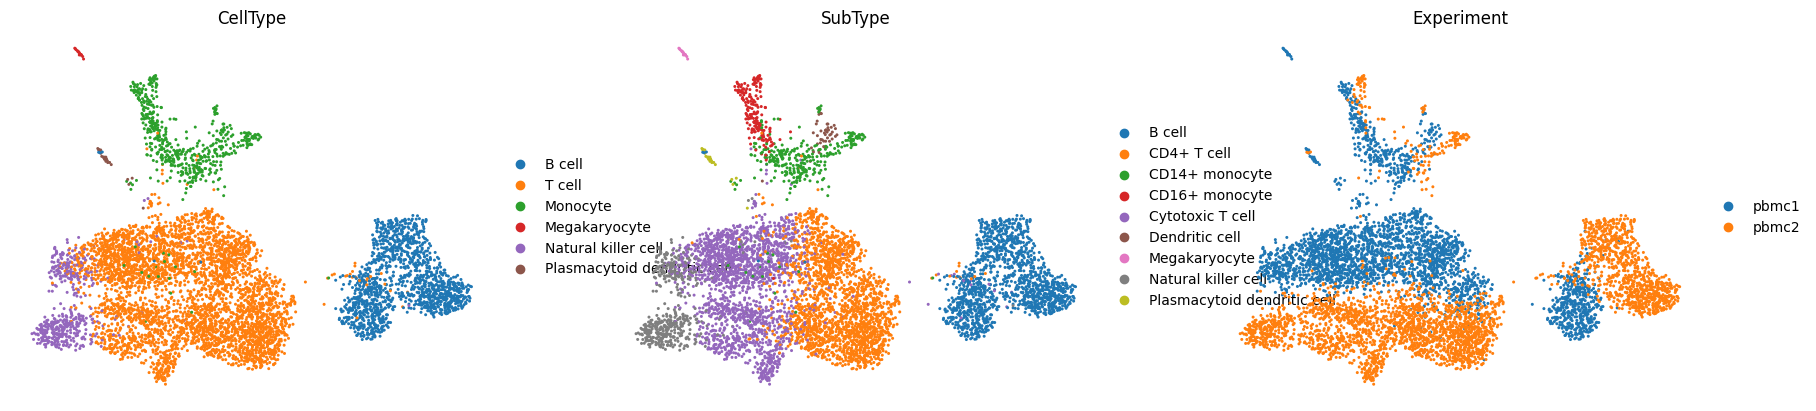

In [6]:
# Coarse cell type (CellType) and fine subtype (SubType).
stypes = {'CD4+ T cell': 'T cell', 'Cytotoxic T cell': 'T cell',
          'CD14+ monocyte': 'Monocyte', 'CD16+ monocyte': 'Monocyte', 'Dendritic cell': 'Monocyte'}
adata.obs['SubType'] = adata.obs['CellType']
adata.obs['CellType'] = adata.obs['CellType'].replace(stypes)
sc.pl.umap(adata, color=['CellType', 'SubType', 'Experiment'], frameon=False)

## Fit scDEF with batch annotations

`batch_key` lets scDEF model per-batch library sizes and gene detection rates — the one direct batch correction it applies; sparsity and the hierarchy do the rest.

In [7]:
ref = scd.scDEF(adata, counts_layer='counts', batch_key='Experiment')
print(ref)
ref.fit(hierarchical_init=True)

INFO:scDEF:Found 2 values for `Experiment` in data: ['pbmc1' 'pbmc2']


scDEF object with 6 layers
	Layer names: L0, L1, L2, L3, L4, L5
	Layer sizes: 100, 40, 16, 6, 3, 1
	alpha parameter: 3.52
	Using BRD
	Number of batches: 2
Contains AnnData object with n_obs × n_vars = 6412 × 4009
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nGene', 'nUMI', 'percent.mito', 'Cluster', 'CellType', 'Experiment', 'Method', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'SubType'
    var: 'features', 'n_cells', 'mt', 'rb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'CellType_colors', 'SubType_colors', 'Experiment_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'


INFO:scDEF:Built hierarchical z/W init from KMeans (100 L0 clusters) using 'X_pca'.
INFO:scDEF:Each epoch contains 26 batches of size 256
 44%|████▎     | 436/1000 [06:54<08:55,  1.05it/s, Loss=4.58e+6, Rel. impr.=-0.00622]
INFO:scDEF:Converged at epoch 437.
INFO:scDEF:Updated adata.var: `gene_scale_0` for batch 0.
INFO:scDEF:Updated adata.var: `gene_scale_1` for batch 1.
INFO:scDEF:Updated adata.obs with layer 0: `L0` and `L0_score` for all factors in layer 0
INFO:scDEF:Updated adata.obsm with layer 0: `X_L0`
INFO:scDEF:Updated adata.uns with layer 0 signatures: `L0_signatures`.
INFO:scDEF:Updated adata.obs with layer 1: `L1` and `L1_score` for all factors in layer 1
INFO:scDEF:Updated adata.obsm with layer 1: `X_L1`
INFO:scDEF:Updated adata.uns with layer 1 signatures: `L1_signatures`.
INFO:scDEF:Updated adata.obs with layer 2: `L2` and `L2_score` for all factors in layer 2
INFO:scDEF:Updated adata.obsm with layer 2: `X_L2`
INFO:scDEF:Updated adata.uns with layer 2 signatures: `L2_si

## Check, diagnose, filter, re-fit, signatures

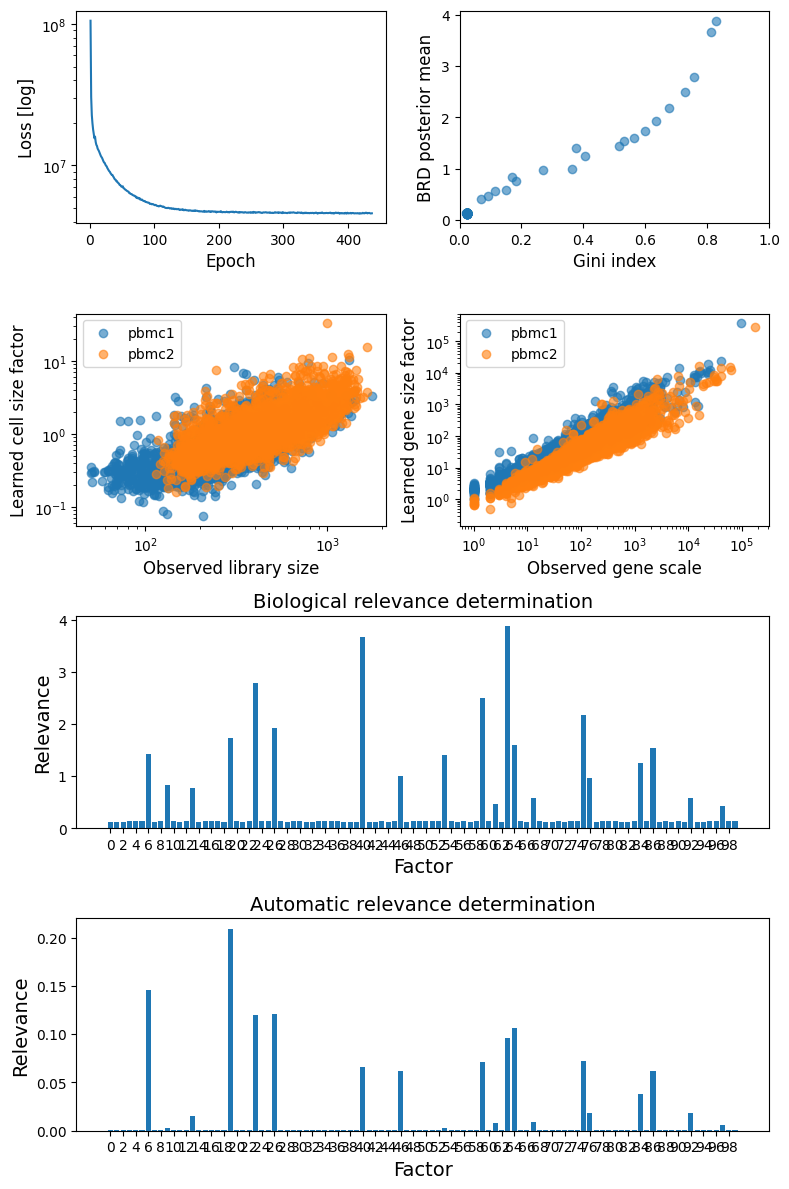

In [8]:
scd.pl.qc(ref)

INFO:scDEF:factor_diagnostics: recomputing cached diagnostics (missing cached upper-layer factor lists; fit revision changed (-1 -> 1)).


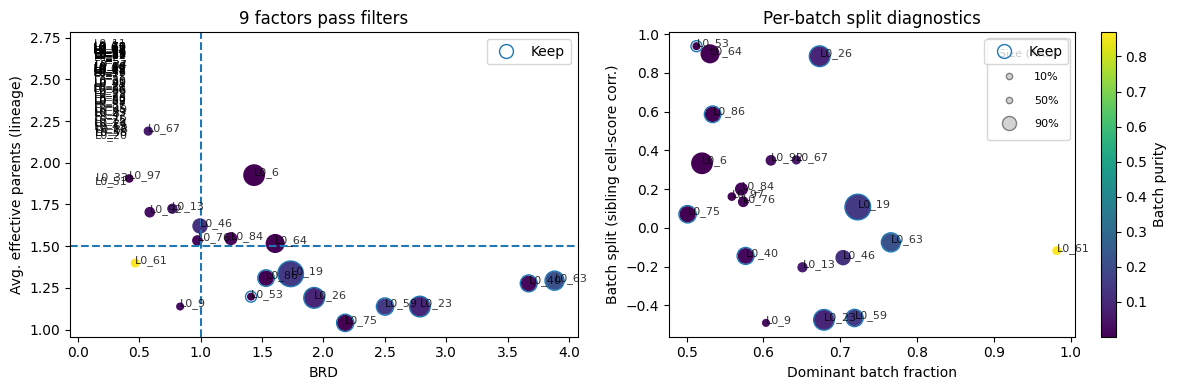

INFO:scDEF:filter_factors: cleared name-keyed caches (L0_signatures, L1_signatures, L2_signatures, L3_signatures, L4_signatures, L5_signatures, _factor_obs_fit_revision, _factor_obs_upper_lists_fixed, confident_signatures, factor_signatures). Re-run scdef.tools.set_confident_signatures to rebuild signatures, or scdef.tools.factor_diagnostics for the full diagnostics.
INFO:scDEF:Updated adata.var: `gene_scale_0` for batch 0.
INFO:scDEF:Updated adata.var: `gene_scale_1` for batch 1.
INFO:scDEF:Updated adata.obs with layer 0: `L0` and `L0_score` for all factors in layer 0
INFO:scDEF:Updated adata.obsm with layer 0: `X_L0`
INFO:scDEF:Updated adata.uns with layer 0 signatures: `L0_signatures`.
INFO:scDEF:Updated adata.obs with layer 1: `L1` and `L1_score` for all factors in layer 1
INFO:scDEF:Updated adata.obsm with layer 1: `X_L1`
INFO:scDEF:Updated adata.uns with layer 1 signatures: `L1_signatures`.
INFO:scDEF:Updated adata.obs with layer 2: `L2` and `L2_score` for all factors in layer 2


[9, 6, 4, 2, 1]


In [9]:
scd.tl.factor_diagnostics(ref, batch_key='Experiment')
scd.pl.factor_diagnostics(ref, annotate_factors=True)
scd.tl.filter(ref, batch_key='Experiment')
ref.fit(hierarchical_init=True)
print([len(fl) for fl in ref.factor_lists])

In [10]:
scd.tl.factor_diagnostics(ref, batch_key='Experiment')  # refreshes diagnostics + gene signatures

INFO:scDEF:factor_diagnostics: recomputing cached diagnostics (missing cached upper-layer factor lists; fit revision changed (-1 -> 2)).


## Batches are integrated

Across layers, cell types separate while the two batches stay mixed — integration without over-correction.

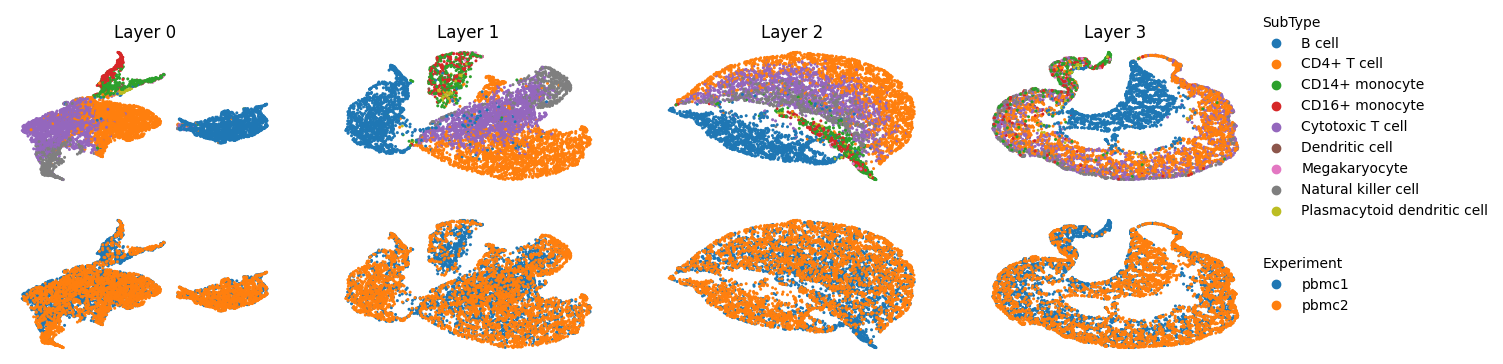

In [11]:
scd.tl.umap(ref)
scd.pl.umap(ref, color=['SubType', 'Experiment'])

## Factors track cell type, not batch

Factors associate strongly with `SubType` and flatly with `Experiment` — no factor is a batch-specific cluster.

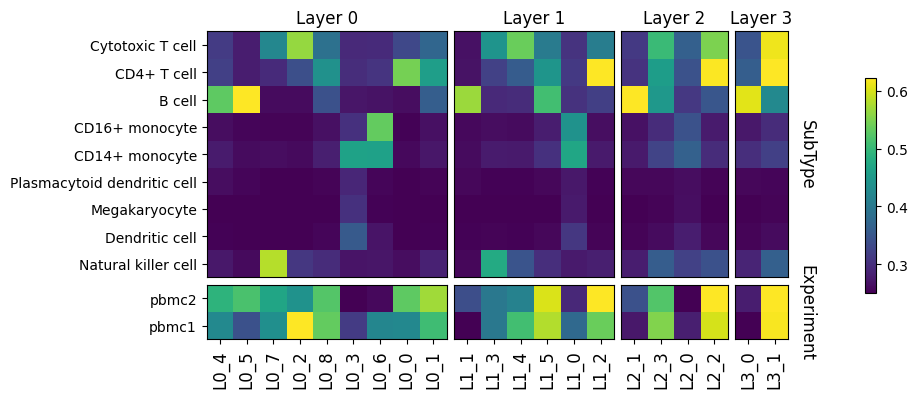

In [12]:
scd.pl.obs_scores(ref, ['SubType', 'Experiment'], mode='weights')

INFO:scDEF:Updated scDEF graph


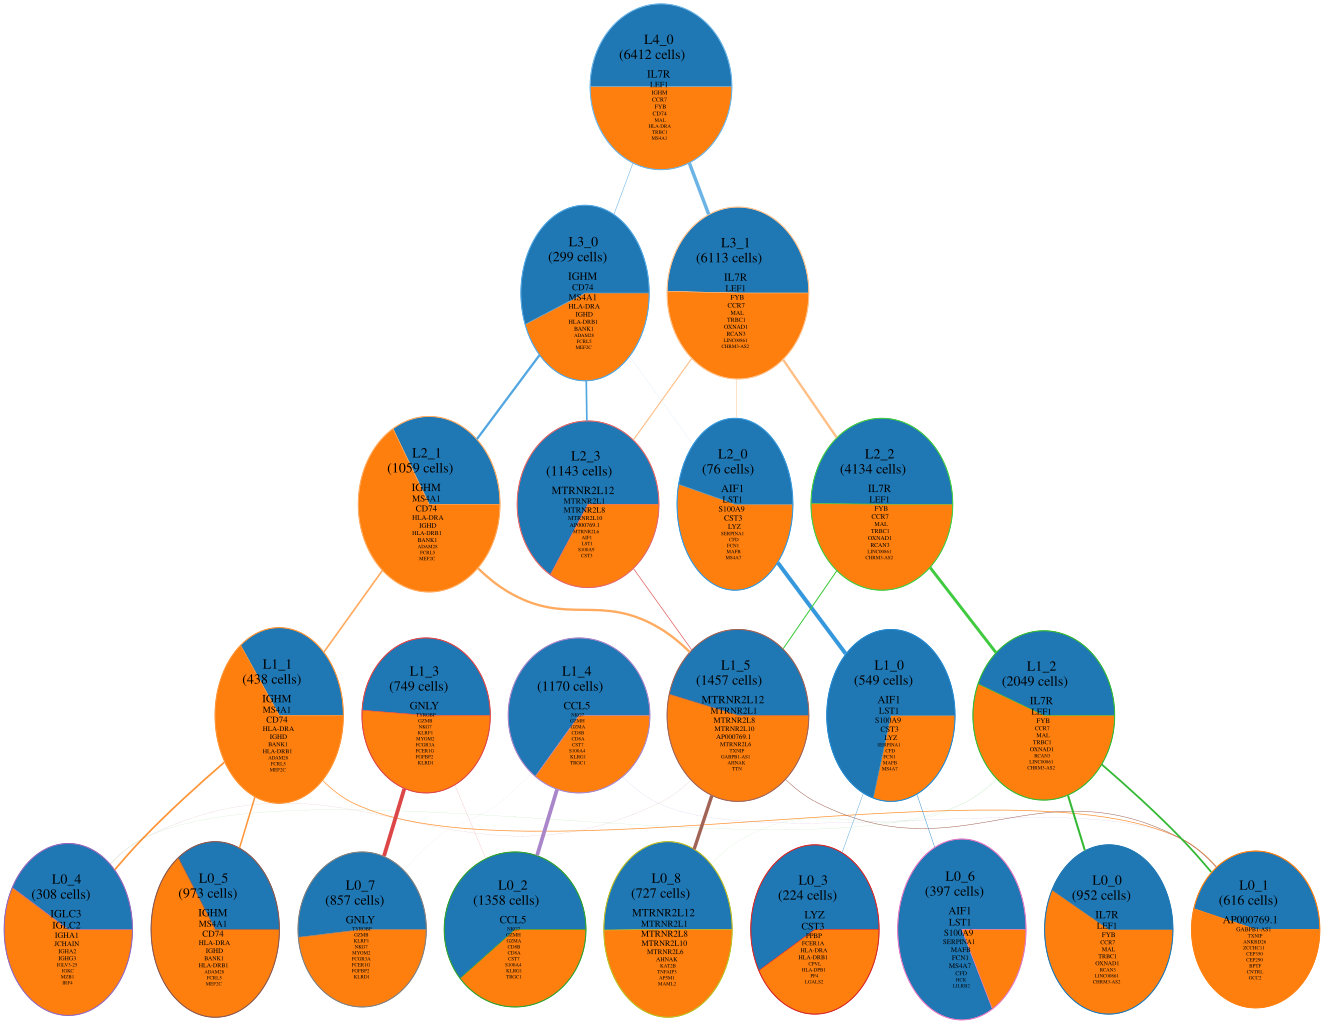

In [13]:
scd.pl.make_graph(ref, wedged='Experiment', n_cells_label=True)  # no batch-dominated node

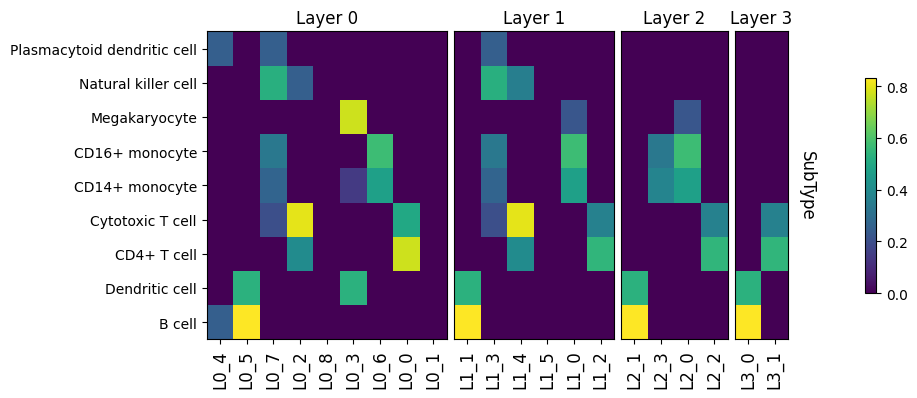

In [14]:
scd.pl.signatures_scores(ref, 'SubType', markers, top_genes=20)

## Same factors used across batches, within a cell type

A per-cell factor heatmap restricted to one cell type and grouped by batch confirms integration at the single-cell level. We look at monocytes — the cell type that *responds* in the interferon notebook — and here both batches use the *same* factors, with no batch-specific program. That is the direct contrast: the analogous heatmap in the interferon notebook shows a condition-specific split.

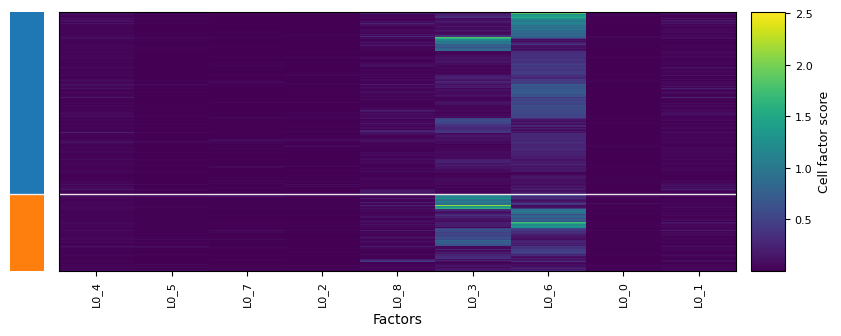

In [15]:
scd.pl.obs_cell_factor_heatmap(ref, subset_obs_key='CellType',
                               subset_obs='Monocyte', group_obs_key='Experiment', values='score')

## Standard batch interpretation: decompose and inspect layer 0

Fitting with `batch_key` corrects a per-gene batch scale. To **see what that term absorbed** and decide whether any residual per-batch structure is technical or biological, re-learn layer 0 without the batch term (`decompose_batch_effects`) and inspect its factors. This is the standard step for *any* multi-batch data set: `ref` stays the representation you use downstream, `dec` is the diagnostic.

In [16]:
dec = scd.scDEF.decompose_batch_effects(ref, top_layer=1)
scd.tl.factor_diagnostics(dec, batch_key='Experiment')  # batch structure + gene signatures for decomposed L0

INFO:scDEF:batch_cell_scale=True: keeping the per-batch cell_scale prior from `Experiment` (2 batches) while gene_scale stays a single shared row.
INFO:scDEF:Found 2 values for `Experiment` in data: ['pbmc1' 'pbmc2']
INFO:scDEF:batch_gene_scale=False: keeping a single shared `gene_scale` row while fitting the per-batch `cell_scale` prior.
INFO:scDEF:Each epoch contains 26 batches of size 256
 38%|███▊      | 153/400 [02:23<03:51,  1.07it/s, Loss=1.17e+7, Rel. impr.=-0.0251]
INFO:scDEF:Converged at epoch 154.
INFO:scDEF:filter_factors: cleared name-keyed caches (L0_signatures, L1_signatures, L2_signatures, L3_signatures, L4_signatures). Re-run scdef.tools.set_confident_signatures to rebuild signatures, or scdef.tools.factor_diagnostics for the full diagnostics.
INFO:scDEF:Updated adata.var: `gene_scale`
INFO:scDEF:Updated adata.obs with layer 0: `L0` and `L0_score` for all factors in layer 0
INFO:scDEF:Updated adata.obsm with layer 0: `X_L0`
INFO:scDEF:Updated adata.uns with layer 0 sig

In [17]:
rep = scd.tl.batch_structure_report(dec, batch_key='Experiment')
rep  # `shape` describes each L0 factor's batch structure

,n_cells,dom_batch,frac_dom_batch,batch_purity_soft,loading_ratio,eff_parents,parent,opp_batch_sibling,branch_auc,shape,gene_scale_affinity_pbmc1,gene_scale_affinity_pbmc2,gene_scale_affinity_max,gene_scale_affinity_batch
L0,,,,,,,,,,,,,,
L0_2,1308,pbmc1,0.918196,0.742577,5.211964,1.354311,L1_4,False,0.993921,branch_skewed,0.501083,-0.501083,0.501083,pbmc1
L0_6,395,pbmc1,0.812658,0.671523,1.157861,1.329291,L1_0,False,0.929761,branch_skewed,0.176747,-0.176747,0.176747,pbmc1
L0_0,838,pbmc2,0.776850,0.657723,2.463990,1.001377,L1_2,False,0.939769,branch_skewed,-0.230948,0.230948,0.230948,pbmc2
L0_1,690,pbmc2,0.755072,0.598762,1.450998,3.027224,L1_1,False,0.922617,overlaid,-0.154858,0.154858,0.154858,pbmc2
L0_4,228,pbmc2,0.710526,0.583303,1.031636,1.383519,L1_1,False,0.922617,branch_skewed,-0.091426,0.091426,0.091426,pbmc2
L0_5,1069,pbmc2,0.659495,0.627095,1.135102,1.056593,L1_1,False,0.922617,balanced,-0.141709,0.141709,0.141709,pbmc2
L0_8,623,pbmc2,0.597111,0.543990,1.025304,1.001397,L1_5,False,0.850416,balanced,-0.067894,0.067894,0.067894,pbmc2
L0_3,215,pbmc1,0.581395,0.566460,1.178260,1.436954,L1_0,False,0.929761,balanced,0.110452,-0.110452,0.110452,pbmc1
L0_7,1046,pbmc2,0.573614,0.506982,0.693754,1.568872,L1_3,False,0.988588,balanced,-0.080038,0.080038,0.080038,pbmc2


The report describes geometry, not cause. For these healthy batches the per-batch structure is **technical** — per-batch views of a shared cell type (`branch_split` / `branch_skewed`). See the split first, then fold it back into the batch-corrected parent. (In the interferon notebook the analogous split is a genuine biological response and is *kept* — same procedure, different decision from the experimental design.)

INFO:scDEF:Updated scDEF graph


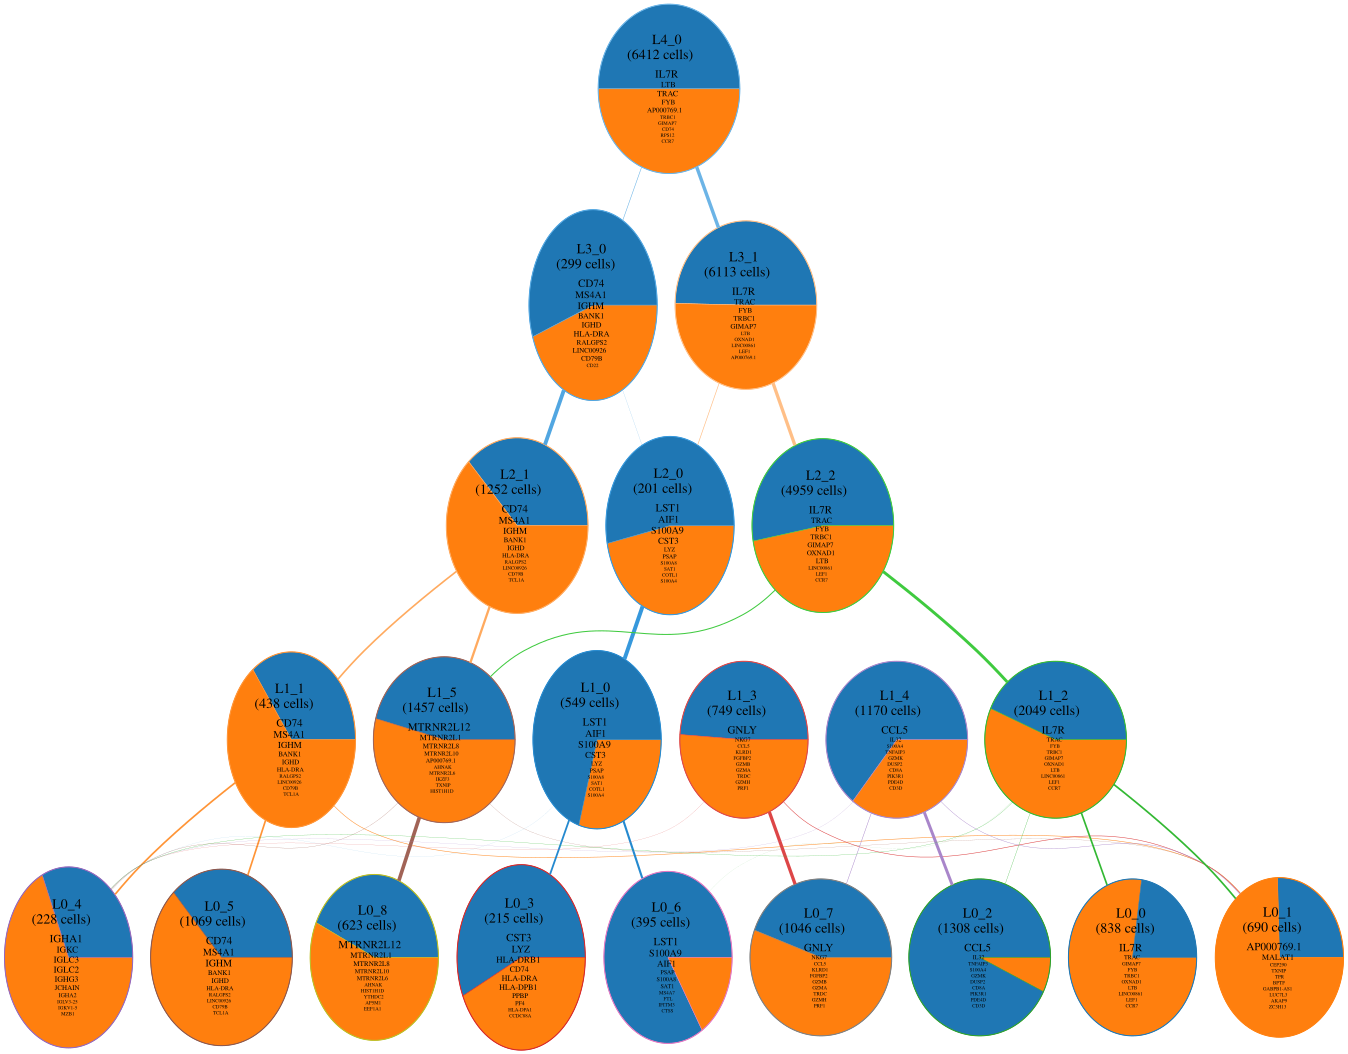

In [18]:
# The per-batch splits: same cell type appearing as two L0 factors under one parent.
scd.pl.make_graph(dec, wedged='Experiment', show_signatures=True, n_cells_label=True)

In [19]:
flagged = rep.index[rep['shape'].isin(['branch_split', 'branch_skewed'])]
print('flagged as batch-technical:', list(flagged))
scd.tl.set_batch_technical_factors(dec, flagged)
scd.tl.factor_batch_correction(dec)

flagged as batch-technical: ['L0_2', 'L0_6', 'L0_0', 'L0_4']


`factor_batch_correction` folds each flagged split back into its shared parent, writing `obsm['X_L0_batch_corrected']` and two label columns: `L0_batch_corrected` (the merged-sibling name, e.g. `L0_7+L0_14`) and `batch_corrected` (each cell's roll-up). Colouring by `Experiment` as well shows the batches stay mixed after folding:

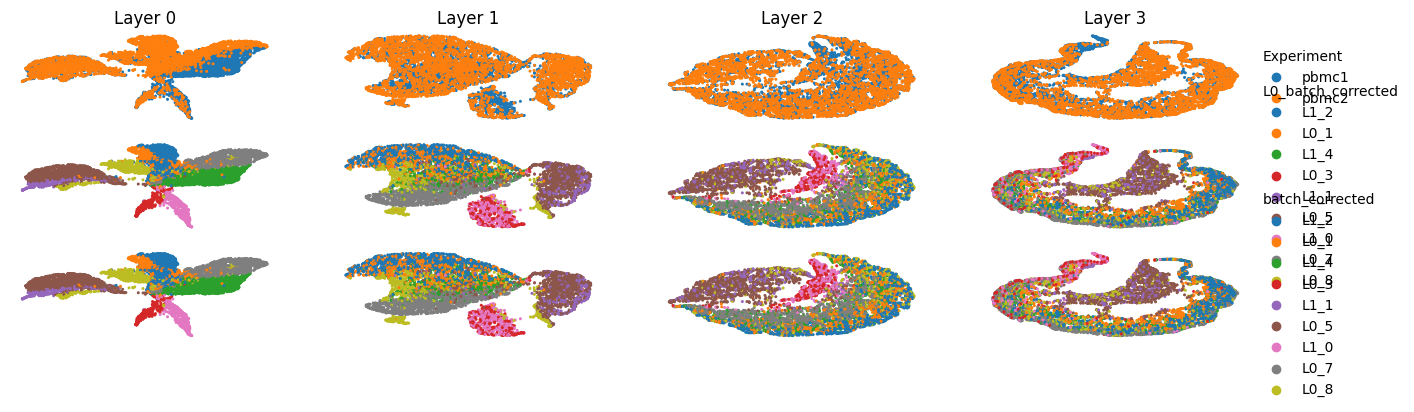

In [20]:
scd.tl.umap(dec)
scd.pl.umap(dec, color=['Experiment', 'L0_batch_corrected', 'batch_corrected'])

## Save the fitted models

In [21]:
ref.save('scdef-pbmcs2b-ref', overwrite=True)   # the representation to use downstream
dec.save('scdef-pbmcs2b-dec', overwrite=True)   # the batch-structure diagnostic